In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.3 MB/s eta 0:00:00


In [8]:
# 1. 라이브러리 임포트 (최상단에 한 번만 선언)
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, confusion_matrix, make_scorer

# 2. 데이터 로드 및 기본 전처리 (한 번만 실행)
print("[0] 데이터 로드 중...")
file_path = '/content/drive/MyDrive/Colab Notebooks/data_team7.csv'
df = pd.read_csv(file_path)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Original Data Shape:", df.shape)

# 특성(Column) 분류 및 공통 타겟 변수 분리
categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate',
                  'JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike',
                  'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                  'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
                  'YearsSinceLastPromotion', 'YearsWithCurrManager']

X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 공통 전처리기 정의
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# =========================================================
# [1] 기본 데이터 K-Fold Cross Validation
# =========================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    X_train_processed_fold = preprocessor.fit_transform(X_train_fold)
    X_test_processed_fold = preprocessor.transform(X_test_fold)

    pos_weight_fold = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()

    model_xgb_kfold = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='auc', max_depth=4,
        learning_rate=0.05, n_estimators=300, scale_pos_weight=pos_weight_fold, random_state=42
    )
    model_xgb_kfold.fit(X_train_processed_fold, y_train_fold)
    print(f"--- Fold {fold+1}/{n_splits} 학습 완료 ---")

# =========================================================
# [2] 하이퍼파라미터 튜닝 (GridSearchCV & Optuna)
# =========================================================
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_valid_proc = preprocessor.transform(X_valid_raw)
X_test_proc = preprocessor.transform(X_test_raw)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 2-1. GridSearchCV
print("--- GridSearchCV ---")
param_grid = {'max_depth': [3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300]}
scoring_metrics = {
    'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision', 'log_loss': make_scorer(log_loss, greater_is_better=False, needs_proba=True)
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight=pos_weight, random_state=42),
    param_grid=param_grid, scoring=scoring_metrics, refit='recall', cv=3, n_jobs=-1, verbose=1
)
grid_search.fit(X_train_proc, y_train)
best_xgb_grid = grid_search.best_estimator_
print("GridSearch 최적 파라미터:", grid_search.best_params_)

# 2-2. Optuna
print("\n--- Optuna 튜닝 ---")
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 300)

    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators,
        scale_pos_weight=pos_weight, random_state=42
    )
    model.fit(X_train_proc, y_train)
    y_pred_proba = model.predict_proba(X_test_proc)[:, 1]
    return average_precision_score(y_test, y_pred_proba)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
print("[Optuna 최적의 하이퍼파라미터]:", study.best_trial.params)

best_xgb_optuna = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    **study.best_trial.params, scale_pos_weight=pos_weight, random_state=42
)
best_xgb_optuna.fit(X_train_proc, y_train)

# =========================================================
# [3] 특성 공학(Feature Engineering) 적용 및 재학습
# =========================================================
def apply_advanced_feature_engineering(df_in):
    df_new = df_in.copy()
    df_new['Total_Satisfaction_Score'] = df_new['EnvironmentSatisfaction'] + df_new['JobSatisfaction'] + df_new['RelationshipSatisfaction'] + df_new['WorkLifeBalance']
    df_new['Income_Per_WorkingYear'] = df_new['MonthlyIncome'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Income_Per_YearAtCompany'] = df_new['MonthlyIncome'] / (df_new['YearsAtCompany'] + 1)
    df_new['Income_Per_Level'] = df_new['MonthlyIncome'] / df_new['JobLevel']
    df_new['Cost_Effectiveness'] = df_new['PercentSalaryHike'] / df_new['PerformanceRating']
    df_new['Burnout_Risk'] = df_new['OverTime'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0) + (5 - df_new['WorkLifeBalance'])
    df_new['Sat_WLB_Interaction'] = df_new['Total_Satisfaction_Score'] * df_new['WorkLifeBalance']
    df_new['Promotion_Speed_Index'] = df_new['JobLevel'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Stagnation_Index'] = df_new['YearsSinceLastPromotion'] / (df_new['YearsAtCompany'] + 1)
    df_new['Job_Hopping_Index'] = df_new['NumCompaniesWorked'] / (df_new['TotalWorkingYears'] + 1)
    df_new['Loyalty_Ratio'] = np.where(df_new['TotalWorkingYears'] > 0, df_new['YearsAtCompany'] / df_new['TotalWorkingYears'], 0)
    return df_new

df_engineered = apply_advanced_feature_engineering(df)
print("Engineered Data Shape:", df_engineered.shape)
display(df_engineered.head(3))

X_eng = df_engineered.drop('Attrition', axis=1)
y_eng = df_engineered['Attrition']

X_train_eng, X_temp_eng, y_train_eng, y_temp_eng = train_test_split(X_eng, y_eng, test_size=0.3, stratify=y_eng, random_state=42)
X_valid_eng, X_test_eng, y_valid_eng, y_test_eng = train_test_split(X_temp_eng, y_temp_eng, test_size=0.5, stratify=y_temp_eng, random_state=42)

numerical_cols_eng = [col for col in X_eng.columns if col not in categorical_cols]
preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_eng),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train_eng_proc = preprocessor_eng.fit_transform(X_train_eng)
X_test_eng_proc = preprocessor_eng.transform(X_test_eng)
pos_weight_eng = (y_train_eng == 0).sum() / (y_train_eng == 1).sum()

model_xgb_eng = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', max_depth=4,
    learning_rate=0.05, n_estimators=300, scale_pos_weight=pos_weight_eng, random_state=42
)
model_xgb_eng.fit(X_train_eng_proc, y_train_eng)


[0] 데이터 로드 중...
Original Data Shape: (1470, 31)

[1] K-Fold Cross Validation 실행
--- Fold 1/5 학습 완료 ---
--- Fold 2/5 학습 완료 ---
--- Fold 3/5 학습 완료 ---
--- Fold 4/5 학습 완료 ---
--- Fold 5/5 학습 완료 ---

[2] 데이터 분할 및 하이퍼파라미터 튜닝 시작
--- GridSearchCV ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearch 최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

--- Optuna 튜닝 ---
[Optuna 최적의 하이퍼파라미터]: {'max_depth': 3, 'learning_rate': 0.09142878328245352, 'n_estimators': 292}

[3] 특성 공학 적용 및 모델 재학습
Engineered Data Shape: (1470, 42)


,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,Income_Per_WorkingYear,Income_Per_YearAtCompany,Income_Per_Level,Cost_Effectiveness,Burnout_Risk,Sat_WLB_Interaction,Promotion_Speed_Index,Stagnation_Index,Job_Hopping_Index,Loyalty_Ratio
0,1,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,665.888889,856.142857,2996.5,3.666667,5,8,0.222222,0.000000,0.888889,0.75
1,0,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,466.363636,466.363636,2565.0,5.750000,2,36,0.181818,0.090909,0.090909,1.00
2,1,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,261.250000,2090.000000,2090.0,5.000000,3,36,0.125000,0.000000,0.750000,0.00



--- 특성 공학이 적용된 최종 모델 학습 완료! ---


<Figure size 800x600 with 0 Axes>

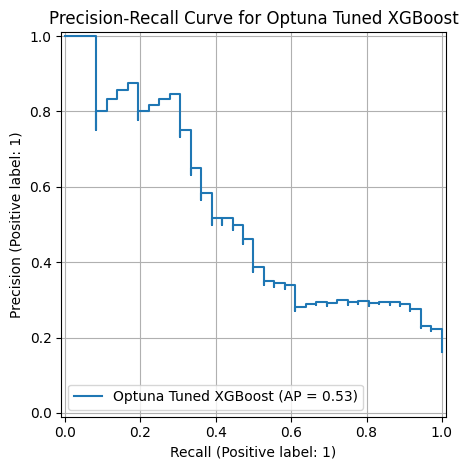

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba_tuned_optuna, name="Optuna Tuned XGBoost"
)
plt.title('Precision-Recall Curve for Optuna Tuned XGBoost')
plt.grid(True)
plt.tight_layout()
plt.savefig('Optuna_XGBoost_Precision-Recall_Curve.pdf')
plt.show()

<Figure size 800x600 with 0 Axes>

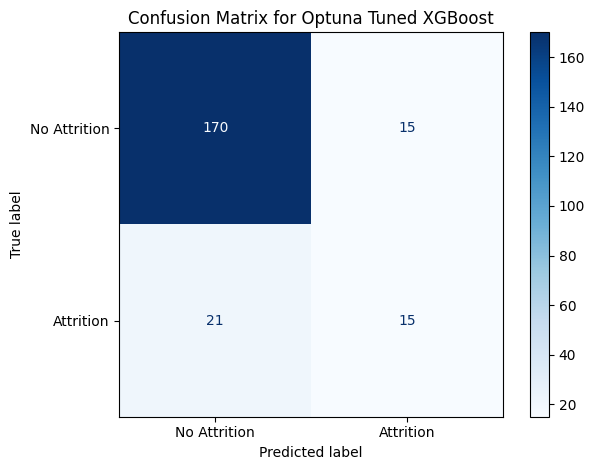

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming `y_test` and `y_pred_tuned_optuna` are available

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned_optuna, display_labels=['No Attrition', 'Attrition'], cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for Optuna Tuned XGBoost')
plt.tight_layout()
plt.savefig('Optuna_XGBoost_Confusion_Matrix.pdf')
plt.show()

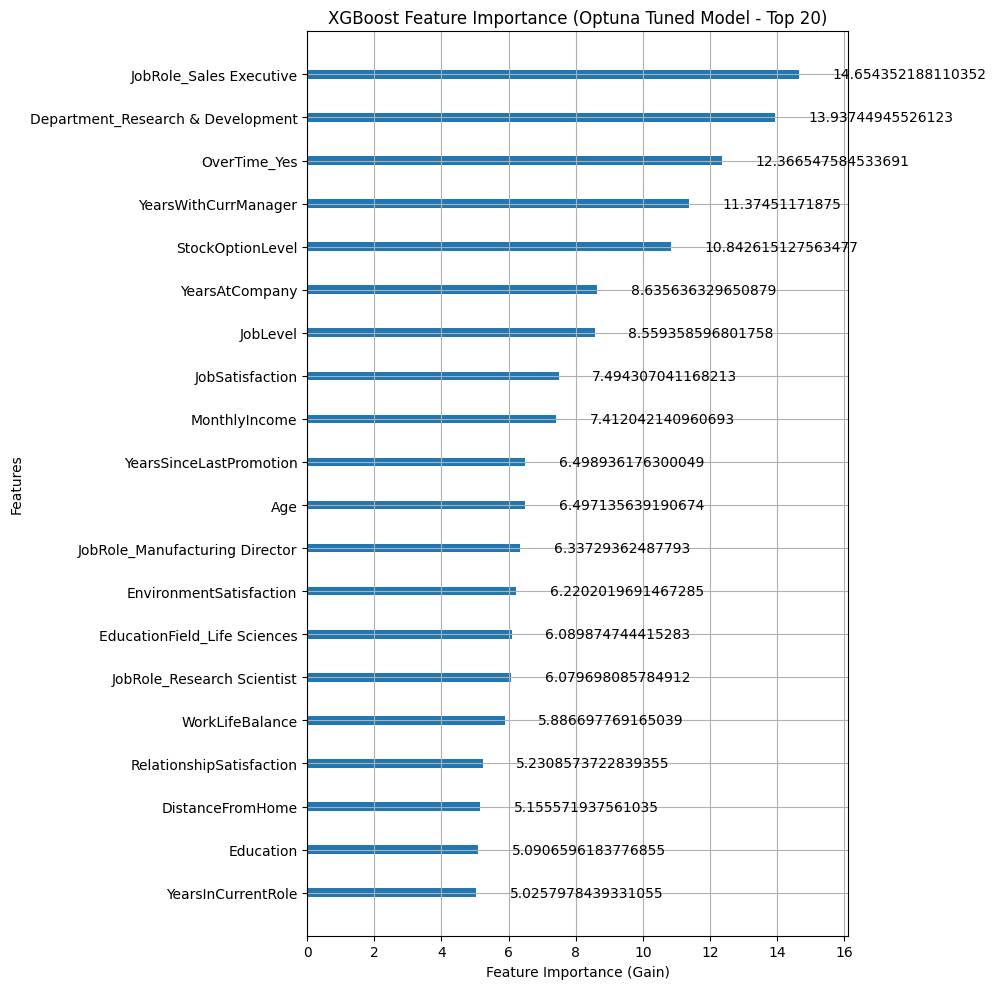

In [11]:
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_cols_optuna = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols_optuna = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction',
                         'HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate',
                         'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
                         'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
                         'YearsSinceLastPromotion', 'YearsWithCurrManager']

reconstructed_preprocessor_optuna = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_optuna),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols_optuna)
    ]
)
X_raw_for_preprocessor = df_clean.drop('Attrition', axis=1)

reconstructed_preprocessor_optuna.fit(X_raw_for_preprocessor)

cat_encoder_optuna = reconstructed_preprocessor_optuna.named_transformers_['cat']
cat_feature_names_optuna = cat_encoder_optuna.get_feature_names_out(categorical_cols_optuna)

feature_names_optuna = numerical_cols_optuna + cat_feature_names_optuna.tolist()

best_xgb_optuna.get_booster().feature_names = feature_names_optuna

fig, ax = plt.subplots(figsize=(10, 10))
xgb.plot_importance(
    best_xgb_optuna,
    max_num_features=20,
    importance_type='gain',
    ax=ax,
    title='XGBoost Feature Importance (Optuna Tuned Model - Top 20)',
    xlabel='Feature Importance (Gain)',
    ylabel='Features'
)
plt.tight_layout()
plt.savefig('Optuna_XGBoost_Feature_Importance.pdf')
plt.show()